## 1. Introduction: Business Understanding


### The Real-World Problem

In today's digital landscape, companies like Apple and Google receive **thousands of mentions on social media every hour**. Manually reading and categorizing this volume of feedback is impossible. Yet understanding public sentiment is critical — a viral negative tweet about a product defect can escalate into a PR crisis within hours, while positive buzz around a product launch can be amplified for marketing advantage. **Companies need an automated, scalable way to monitor and classify sentiment in real-time.**

### Stakeholders and How They Would Use This Model

Stakeholder How They Would Use the Model

**Product Marketing Teams** Monitor sentiment during product launches (e.g., new iPhone, Google Pixel). Identify which features generate positive buzz and which receive criticism. Adjust messaging in real-time.

**Customer Support / CX Teams** Set up alerts for spikes in negative sentiment to proactively address widespread product issues before they escalate. Prioritize support resources.

**Product Development Teams** Analyze negative tweets to identify recurring complaints (e.g., battery life, software bugs). Feed insights into the product roadmap for future iterations.

**Executive Leadership / PR** Track overall brand health over time via sentiment dashboards. Compare sentiment between Apple vs. Google products. Prepare data-driven responses to media inquiries.

### Our Solution
We build an NLP classifier that can automatically categorize a tweet as **positive**, **negative**, or **neutral**  enabling stakeholders to process thousands of tweets per minute and power automated dashboards, alerts, and reports.

## 2. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

# NLP - NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning - scikit-learn
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score,
                              ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline


In [3]:

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')



## 3. Data Understanding

### 3.1 Data Source

The dataset comes from **CrowdFlower** (now Figure Eight / Appen) via [data.world](https://data.world/crowdflower/brands-and-product-emotions). It contains **9,093 tweets** collected during the 2011 South by Southwest (SXSW) conference in Austin, Texas. Each tweet was reviewed by human raters who assessed:

1. **Which brand or product** the tweet is directed at (e.g., iPhone, iPad, Google, Android)
2. **The sentiment** expressed toward that brand/product (Positive, Negative, Neutral, or "I can't tell")

### Why This Dataset Is Suitable

##### Criterion  Assessment 

 **Labeled data**  Human-annotated sentiment labels enable supervised classification — no need for unsupervised labeling heuristics
 
 **Real-world text**  Tweets are authentic social media posts with natural language patterns (abbreviations, hashtags, slang, sarcasm) 
 
 **Multiclass labels**  Positive/Negative/Neutral categories match real business needs for brand monitoring 
 
 **Relevant domain**  Apple and Google are among the world's most discussed brands — findings generalize to tech brand monitoring 
 
 **Manageable size**  ~9,000 tweets is large enough for classical ML models while remaining computationally feasible on local machines 

### Data Limitations (Identified Upfront)

1. **Temporal bias** — All tweets are from SXSW 2011. Language patterns, products (iPhone 4, iPad 1), and slang have changed dramatically. The model may not generalize to modern tweets.
2. **Event-specific context** — SXSW is a tech conference, so the audience skews tech-savvy and enthusiastic. Sentiment distribution may differ from everyday Twitter discourse.
3. **Annotation ambiguity** — The dataset includes an "I can't tell" label, indicating that even human raters found some tweets ambiguous. This sets a ceiling on achievable model accuracy.
4. **No demographic metadata** — We have no information about tweet authors (location, follower count, verified status), which could provide useful context signals.
5. **Class imbalance** — As we'll see below, the neutral class heavily dominates, making minority class (negative) prediction challenging.


In [4]:
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin-1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion


### 3.2 DATA SET STRUCTURE AND QUALITY

In [5]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicated Rows ===')
print(f'Duplicate rows: {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.1f}%)')

=== Data Types ===
tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object

=== Missing Values ===
tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

=== Duplicated Rows ===
Duplicate rows: 22 (0.2%)


In [6]:
# Rename columns for clarity
# Original: tweet_text, emotion_in_tweet_is_directed_at,
#           is_there_an_emotion_directed_at_a_brand_or_product
df.columns = ['tweet_text', 'product', 'sentiment']

print(f'Renamed columns: {df.columns.tolist()}')
print(f'\nSentiment distribution:\n{df["sentiment"].value_counts()}')
print(f'\nProduct distribution (top 10):\n{df["product"].value_counts().head(10)}')

Renamed columns: ['tweet_text', 'product', 'sentiment']

Sentiment distribution:
sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

Product distribution (top 10):
product
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64


### 3.3 Feature Descriptions and Justification

The dataset contains three columns. Below we describe each, its properties, and why it is included or excluded from the analysis.

| Feature | Type | Description | Role in Analysis |
|---|---|---|---|
| `tweet_text` | Text (string) | The raw tweet content posted on Twitter | **Primary input feature.** Contains the linguistic signals (word choice, punctuation, phrasing) that indicate sentiment. |
| `product` | Categorical | The brand or product the tweet is directed at (e.g., iPhone, iPad, Google, Android) | **Not used as a model feature.** Including it would make the model learn brand-specific sentiment rather than generalizable language patterns. However, we examine it during EDA. |
| `sentiment` | Categorical | Human-annotated sentiment label | **Target variable.** Four original labels: "Positive emotion", "Negative emotion", "No emotion toward brand or product", "I can't tell". |

**Target Variable Decision:** The "I can't tell" label represents tweets where even human annotators couldn't determine sentiment. Including these would introduce noise — if humans can't label them, we shouldn't expect a model to. We will examine their prevalence and remove them.

### 3.4 Class Distribution and Descriptive Statistics

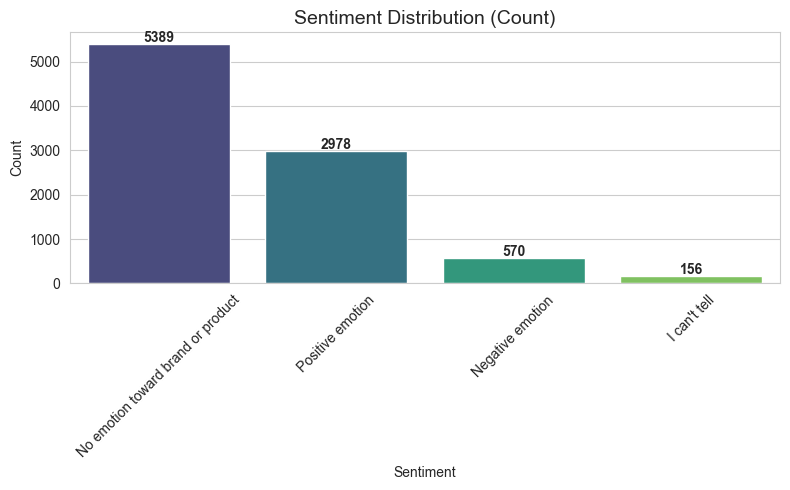

=== Class Distribution ===
                                    Count  Percentage
sentiment                                            
No emotion toward brand or product   5389        59.3
Positive emotion                     2978        32.8
Negative emotion                      570         6.3
I can't tell                          156         1.7


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

sentiment_counts = df['sentiment'].value_counts()

sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            ax=ax, palette='viridis')
ax.set_title('Sentiment Distribution (Count)', fontsize=14)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(sentiment_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('=== Class Distribution ===')
dist = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': (sentiment_counts / len(df) * 100).round(1)
})
print(dist)

**Class Distribution Analysis:**

The dataset exhibits significant **class imbalance**:
- **Neutral** ("No emotion toward brand or product") dominates at ~60% of all tweets
- **Positive** ("Positive emotion") comprises ~33%
- **Negative** ("Negative emotion") is the minority at only ~6%
- **"I can't tell"** represents ~2% — these are ambiguous even to human raters

**Implications for modeling:**
1. A naive baseline predicting "neutral" for every tweet would achieve ~60% accuracy — **accuracy is therefore a misleading metric**
2. We will use **weighted F1-score** as our primary metric (accounts for class sizes)
3. We will use **class weights** (`class_weight='balanced'`) in our models
4. We will use **stratified train/test splits** to preserve class proportions
5. We will **drop "I can't tell"** rows since they represent annotator uncertainty, not a meaningful sentiment class

In [8]:
# Drop "I can't tell" — annotator uncertainty, not a meaningful class
cant_tell_count = df[df['sentiment'] == "I can't tell"].shape[0]
print(f'Removing {cant_tell_count} "I can\'t tell" rows '
      f'({cant_tell_count/len(df)*100:.1f}%)')

df = df[df['sentiment'] != "I can't tell"].copy()
print(f'Dataset after removal: {df.shape[0]} rows')
print(f'\nRemaining sentiment distribution:\n{df["sentiment"].value_counts()}')

Removing 156 "I can't tell" rows (1.7%)
Dataset after removal: 8937 rows

Remaining sentiment distribution:
sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
Name: count, dtype: int64


In [9]:
# Descriptive statistics for text properties
df['tweet_length'] = df['tweet_text'].astype(str).str.len()
df['word_count'] = df['tweet_text'].astype(str).str.split().str.len()

print('=== Descriptive Statistics: Tweet Text Properties ===\n')
text_stats = df.groupby('sentiment')[['tweet_length', 'word_count']].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(1)
print(text_stats)

print(f'\n=== Overall Statistics ===')
print(f'Total tweets:          {len(df)}')
print(f'Mean tweet length:     {df["tweet_length"].mean():.1f} characters')
print(f'Mean word count:       {df["word_count"].mean():.1f} words')
print(f'Median tweet length:   {df["tweet_length"].median():.1f} characters')
print(f'Median word count:     {df["word_count"].median():.1f} words')

=== Descriptive Statistics: Tweet Text Properties ===

                                   tweet_length                               \
                                          count   mean   std min median  max   
sentiment                                                                      
Negative emotion                            570  109.4  27.4  38  114.0  158   
No emotion toward brand or product         5389  104.2  27.2   3  108.0  178   
Positive emotion                           2978  105.6  27.1  25  110.0  170   

                                   word_count                            
                                        count  mean  std min median max  
sentiment                                                                
Negative emotion                          570  18.8  5.1   6   19.0  31  
No emotion toward brand or product       5389  17.4  4.9   1   18.0  32  
Positive emotion                         2978  18.2  4.9   4   19.0  33  

=== Overall Statist

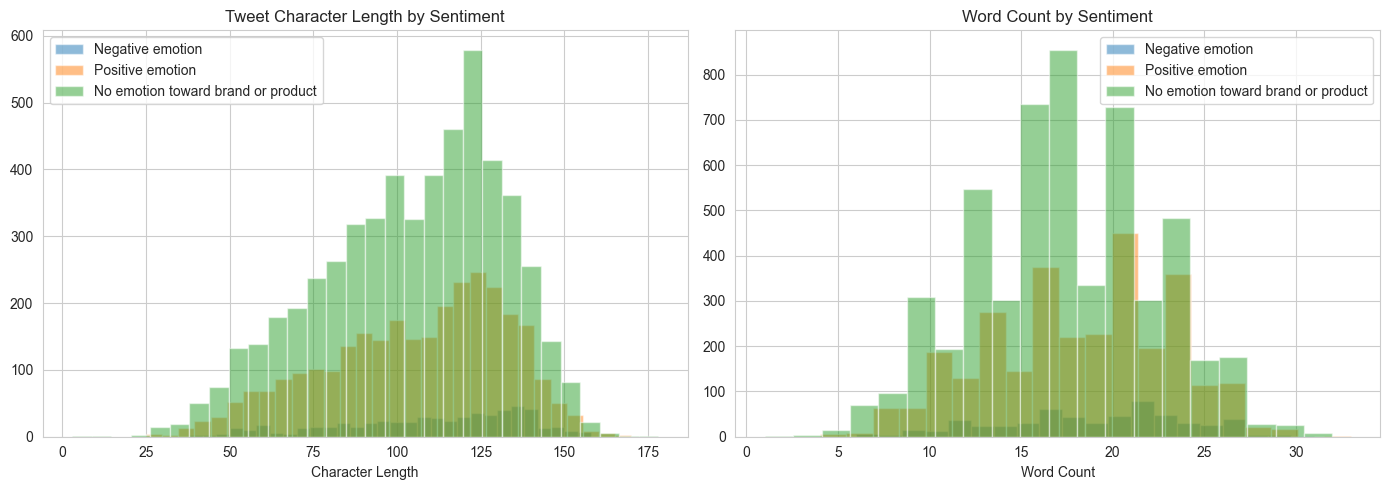

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]
    axes[0].hist(subset['tweet_length'], alpha=0.5, label=sentiment, bins=30)
    axes[1].hist(subset['word_count'], alpha=0.5, label=sentiment, bins=20)

axes[0].set_title('Tweet Character Length by Sentiment')
axes[0].set_xlabel('Character Length')
axes[0].legend()
axes[1].set_title('Word Count by Sentiment')
axes[1].set_xlabel('Word Count')
axes[1].legend()
plt.tight_layout()
plt.show()